# Simulating a random process based on the target spectral density function 

This code demonstrates how to generate a sample random process based on the spectral density function, as we discussed in the lecture video. Note that we already used this code when we were trying to estimate the spectral density function and bandwidth based on data, but I did not give you a lot of detail about how the simulation process works. This code is more clearly commented in this regard.  

# Step 1: Import the necessary packages, initialize the random process, and set input parameters
First, we need to import the numpy packages that will be used subsequently in this code. Then we identify the length of the specimen and the number of points at which the random process will be available. You can leave these as the values listed below. The simulated sample is a function of time, so we first establish a vector of time, with N1=2^10=1024 evenly spaced points between 0 and the total duration L1, assumed here to be 10. The sample process is generated in the frequency domain, so we also establish a similar vector of frequencies. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Generate vector for time t: 2^9=512 evenly spaced points between 0 and 10
L1=10
N1=np.power(2,10)
t=np.linspace(0,L1,N1)
dt=t[2]-t[1]

#Generate vector for frequencies k: 2^10=1024 evenly spaced points between 0 and 10
ku=N1*np.pi/20
Nk=np.power(2,9)
k=np.linspace(0,ku,Nk)
dk=k[2]-k[1]

# Step 2: Generate the random process

The following code generates a single sample of a stationary 1D Gaussian random process with mean 0 and variance Var. If a different mean is needed, this is easily accomplished by adding the value of the mean to every entry in the sample random process. 

## Define a function to generate a random process
Below is a function that will generate a process with spectral density function $S(\omega)=\pi be^{-b|\omega|}$. The parameter b is related the correlation length. Remember what the spectral density function represents - contributions of each frequency to the variance of the random process. Therefore, we can generate a random process with a given spectral density function by adding every frequency's contribution to the process together. In other words, we add the product of the discretized spectral density function value ($S(\omega_k)\Delta\omega$) and $e^{i(\omega_kt+\phi_k)}$. Note that $\phi_k$ in this expression is a random phase angle corresponding to each frequency. These are easy to generate, since they are independent random numbers on the range between 0 and $2\pi$. Since the phase angles are generated randomly, this gives us a different realization of the random process $f$ every time we run this.  

In [2]:
def simulation (b,Nfreq,Npts,kk,deltak,var):

    #Generate a vector of random phase angles between 0 and pi
    phi = np.random.rand(1,Nfreq)*2*np.pi

    #Assign the spectral density function
    S=var/2*b*np.exp(-b*kk)

    #Use spectral representation to generate random field f as a function of t
    expo=np.exp(1j*(np.outer(kk,t)+np.outer(phi,np.ones(Npts))))
    fmat=np.sqrt(2)*np.real(np.multiply(np.outer(np.power(2*S*deltak,.5),np.ones(Npts)),expo))
    f=np.sum(fmat,axis=0)
    
    return f

Note that the code above generates a vector of random phase angles. These random numbers are the way in which randomness is introduced into each generation of the random process. The idea is that each frequency is assigned a random phase angle, that is uniformly distributed between 0 and 2$\pi$.

The function below generates a plot of a given random process f, as a function of time tt.

In [3]:
#generate plots of random process
def ranplot(tt,f,b):
    plt.plot(tt,f)
    plt.xlabel('time')
    plt.ylabel('random process f(time)')
    plottitle="b = {}".format(b)
    plt.title(plottitle)
    plt.show()


## Generate 3 random processes with the same variance and parameter b
First, the code will generate 3 different processes with the same variance Var and parameter b. 

0.8016146087221179


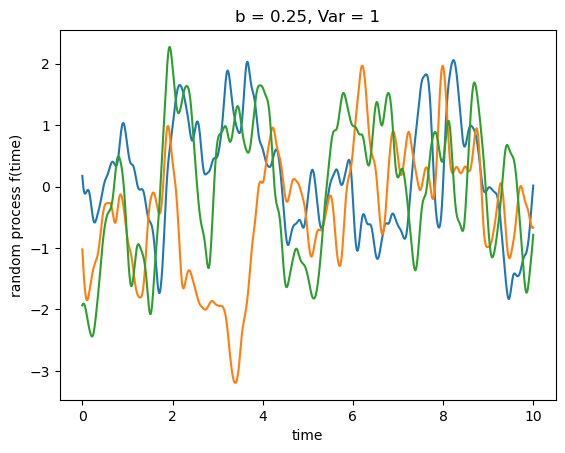

In [4]:
b1 = .25
Var=1
f1=simulation(b1,Nk,N1,k,dk,Var)
f2=simulation(b1,Nk,N1,k,dk,Var)
f3=simulation(b1,Nk,N1,k,dk,Var)
print(np.var(f1))
plt.plot(t,f1)
plt.plot(t,f2)
plt.plot(t,f3)
plt.xlabel('time')
plt.ylabel('random process f(time)')
plottitle="b = {}, Var = {}".format(b1,Var)
plt.title(plottitle)
plt.show()

## Generate 3 random processes with the same parameter b but different variance
What happens to the samples as the variance is increased?

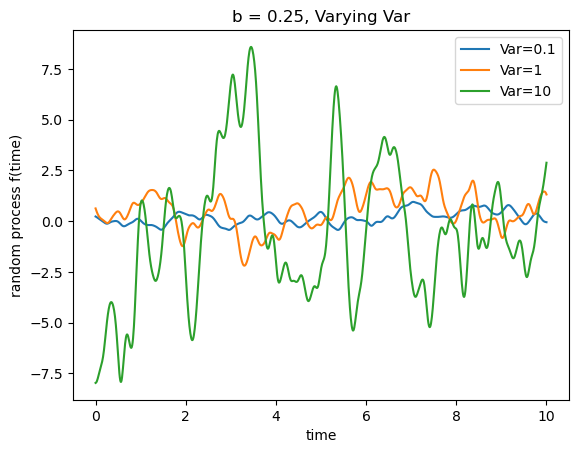

In [5]:
b1 = .25
Var=.1
f1=simulation(b1,Nk,N1,k,dk,Var)
Var=1
f2=simulation(b1,Nk,N1,k,dk,Var)
Var=10
f3=simulation(b1,Nk,N1,k,dk,Var)
plt.plot(t,f1)
plt.plot(t,f2)
plt.plot(t,f3)
plt.xlabel('time')
plt.ylabel('random process f(time)')
plottitle="b = {}, Varying Var".format(b1)
plt.legend(['Var=0.1', 'Var=1', 'Var=10'])
plt.title(plottitle)
plt.show()

## Generate 3 random processes with the same variance but different parameter b
What happens to the samples as b changes?

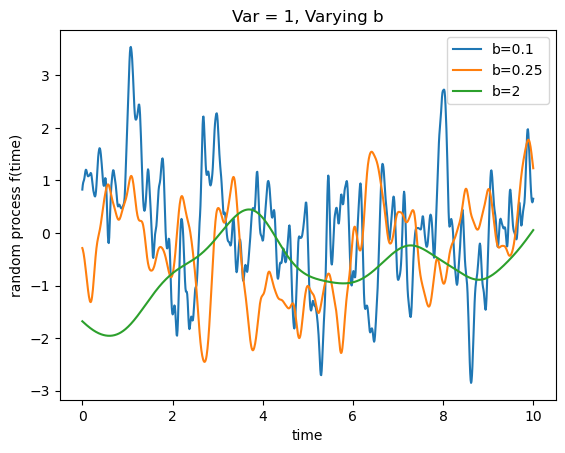

In [6]:
b1 = .1
Var=1
f1=simulation(b1,Nk,N1,k,dk,Var)
b1=.25
f2=simulation(b1,Nk,N1,k,dk,Var)
b1=2
f3=simulation(b1,Nk,N1,k,dk,Var)
plt.plot(t,f1)
plt.plot(t,f2)
plt.plot(t,f3)
plt.xlabel('time')
plt.ylabel('random process f(time)')
plottitle="Var = {}, Varying b".format(Var)
plt.title(plottitle)
plt.legend(['b=0.1', 'b=0.25', 'b=2'])

plt.show()

You might notice that this simulation is faster than the simulation based on correlation function. In fact, spectral representation uses fast Fourier transform to perform a very efficient simulation, and it is therefore the preferred approach.